# Smart CV Analyzer — 02: NER & Feature Extraction

Builds the full NLP preprocessing and feature extraction pipeline.

| Step | Library | Output |
|------|---------|--------|
| Text cleaning (v2) | NLTK, regex | `Resume_Cleaned_v2` |
| Lemmatization | NLTK `WordNetLemmatizer` | overwrite `Resume_Cleaned_v2` |
| Post-EDA WordCloud | wordcloud, matplotlib | visual |
| TF-IDF vectorisation | scikit-learn `TfidfVectorizer` | `resume_matrix`, `tfidf_vectorizer` |
| NER skill extraction | spaCy `EntityRuler` + `PhraseMatcher` | per-doc skill sets |
| Fuzzy vocab builder | RapidFuzz | `smart_skills.json` |

**Inputs:** `notebooks/data/processed/merged_resumes.csv`, `job_descriptions.csv`
**Outputs:** `models/tfidf_model.pkl`, `models/smart_skills.json`

In [1]:
import os, sys, re, json, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",   quiet=True)

import spacy
from spacy.matcher import PhraseMatcher

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from rapidfuzz import process, fuzz
import PyPDF2

sys.path.append(os.path.abspath(os.path.join("..")))
print("Imports OK.")

Imports OK.


## 1. Load Data from Notebook 01

In [2]:
PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODEL_DIR     = os.path.join(os.getcwd(), "..", "models")
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), ".."))
CV_PDF_PATH   = os.path.join(PROJECT_ROOT, "data", "raw", "CV_ATS_JOSEP_NATANAEL_PASARIBU .pdf")

df_resume_merged = pd.read_csv(os.path.join(PROCESSED_DIR, "merged_resumes.csv"))
df_jobs          = pd.read_csv(os.path.join(PROCESSED_DIR, "job_descriptions.csv"))

print(f"Resumes : {df_resume_merged.shape[0]:,} rows | {df_resume_merged['Category'].nunique()} categories")
print(f"Jobs    : {df_jobs.shape[0]:,} rows")

Resumes : 2,648 rows | 48 categories
Jobs    : 10,000 rows


## 2. Text Preprocessing Pipeline

### v1 (Baseline) vs v2 (Production)

| Step | v1 | v2 |
|------|----|----|
| Lowercase | ✓ | ✓ |
| Remove URLs / emails | ✓ | ✓ |
| Strip non-ASCII / mojibake | — | ✓ |
| Remove punctuation & digits | ✓ | ✓ |
| Remove English stopwords | — | ✓ |

v1 is shown for reference. All downstream processing uses **v2**.

In [3]:
# ── Baseline v1 (kept for comparison only) ───────────────────────────────────
def clean_resume_text(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\x00-\x7f]', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# ── Production v2 (used everywhere downstream) ───────────────────────────────
_stop_words = set(stopwords.words("english"))

def clean_resume_text_v2(text):
    text = str(text).lower()
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^\x00-\x7f]', ' ', text)     # strip mojibake / non-ASCII
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    words = [w for w in text.split() if w not in _stop_words]
    return re.sub(r'\s+', ' ', ' '.join(words)).strip()

sample = df_resume_merged.iloc[0]["Resume"]
print("=== v1 (first 300 chars) ==="); print(clean_resume_text(sample)[:300])
print("\n=== v2 (first 300 chars) ==="); print(clean_resume_text_v2(sample)[:300])

=== v1 (first 300 chars) ===
skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm na ve bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality red

=== v2 (first 300 chars) ===
skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm na bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduct


In [4]:
print("Applying v2 to all resumes...")
df_resume_merged["Resume_Cleaned_v2"] = df_resume_merged["Resume"].apply(clean_resume_text_v2)

print("Applying v2 to job descriptions...")
df_jobs["Responsibilities_Cleaned_v2"] = df_jobs["responsibilities"].apply(clean_resume_text_v2)
df_jobs["Skills_Cleaned_v2"]           = df_jobs["required_skills"].apply(clean_resume_text_v2)
print("Done.")

Applying v2 to all resumes...
Applying v2 to job descriptions...
Done.


## 3. Lemmatization

Map each token to its base dictionary form using NLTK `WordNetLemmatizer`.
Preferred over stemming because lemmas are linguistically valid words
(*studies → study*, not *studi*).

In [5]:
_lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join(_lemmatizer.lemmatize(w) for w in text.split())

print("Lemmatizing resumes...")
df_resume_merged["Resume_Cleaned_v2"] = df_resume_merged["Resume_Cleaned_v2"].apply(lemmatize_text)

print("Lemmatizing job descriptions...")
df_jobs["Job_Text_Clean"] = (
    df_jobs["Skills_Cleaned_v2"] + " " + df_jobs["Responsibilities_Cleaned_v2"]
).apply(lemmatize_text)

display(df_resume_merged[["Category", "Resume_Cleaned_v2"]].head(2))

Lemmatizing resumes...
Lemmatizing job descriptions...


,Category,Resume_Cleaned_v2
0,Data Science,skill programming language python panda numpy ...
1,Data Science,education detail may may b e uit rgpv data sci...


## 4. Post-Preprocessing EDA

WordCloud confirms the pipeline surfaces domain-relevant terms after noise removal.

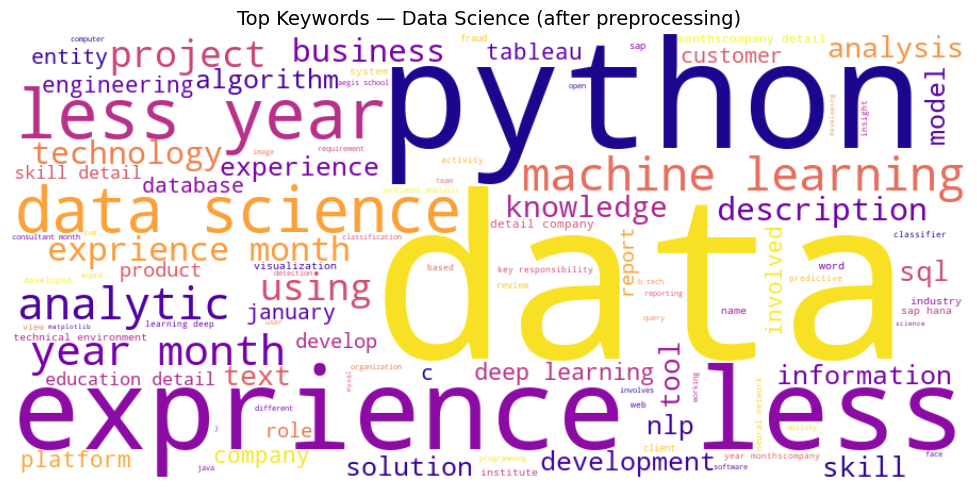

In [6]:
category = "Data Science"
corpus   = " ".join(df_resume_merged[df_resume_merged["Category"] == category]["Resume_Cleaned_v2"].dropna())
wc = WordCloud(width=900, height=420, background_color="white", colormap="plasma", max_words=100).generate(corpus)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
plt.title(f"Top Keywords — {category} (after preprocessing)", fontsize=14)
plt.tight_layout(); plt.show()

## 5. TF-IDF Feature Extraction

Convert preprocessed text to sparse numeric vectors.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `max_features` | 5 000 | Memory bound |
| `ngram_range` | (1, 2) | Capture bigrams (*machine learning*) |
| `sublinear_tf` | True | Log-scale TF to dampen dominant terms |
| `min_df` | 2 | Drop hapax legomena (corpus noise) |

In [8]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                   sublinear_tf=True, min_df=2)
resume_matrix = tfidf_vectorizer.fit_transform(df_resume_merged["Resume_Cleaned_v2"])
print(f"Matrix shape: {resume_matrix.shape}  (resumes × vocabulary)")

features   = tfidf_vectorizer.get_feature_names_out()
bigrams    = [f for f in features if " " in f]
bi_idx     = [list(features).index(b) for b in bigrams]
bi_weights = np.asarray(resume_matrix[:, bi_idx].sum(axis=0)).flatten()
top20      = sorted(zip(bigrams, bi_weights), key=lambda x: -x[1])[:20]
print("Top-20 Bigrams by corpus weight:")
for i, (term, w) in enumerate(top20, 1):
    print(f"  {i:2d}. '{term}'  ({w:.1f})")

Matrix shape: (2648, 5000)  (resumes × vocabulary)
Top-20 Bigrams by corpus weight:
   1. 'city state'  (87.8)
   2. 'company name'  (79.9)
   3. 'name city'  (77.4)
   4. 'customer service'  (46.6)
   5. 'high school'  (29.2)
   6. 'microsoft office'  (27.6)
   7. 'university city'  (26.7)
   8. 'current company'  (26.7)
   9. 'project management'  (25.8)
  10. 'human resource'  (24.1)
  11. 'communication skill'  (23.9)
  12. 'business development'  (21.8)
  13. 'problem solving'  (21.6)
  14. 'bachelor science'  (21.4)
  15. 'team member'  (20.8)
  16. 'college city'  (19.7)
  17. 'manager company'  (19.6)
  18. 'business administration'  (19.6)
  19. 'policy procedure'  (19.5)
  20. 'social medium'  (19.0)


## 6. NER — spaCy EntityRuler & PhraseMatcher

**EntityRuler** pattern-locks curated tech terms to a custom `SKILL` label.
**PhraseMatcher** enables explicit keyword-based gap analysis.
Together these form the NER core of `src/extraction/engine.py`.

In [9]:
def extract_text_from_pdf(path):
    text = ""
    try:
        with open(path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            for page in reader.pages:
                text += (page.extract_text() or "") + " "
    except Exception as e:
        text = f"Error: {e}"
    return text

cv_text_raw = extract_text_from_pdf(CV_PDF_PATH)
print(f"PDF extracted: {len(cv_text_raw)} chars")
print(cv_text_raw[:400])

PDF extracted: 3219 chars
A dedicated Computer Science student at BINUS University specializing in Artificial Intelligence and
Full-stack Development. Proven track record of developing functional Deep Learning models for
image classification and designing efficient relational database systems. A natural leader with
demonstrated abilities in mentoring freshmen, organizing charity events, and conducting technical
workshops i


In [10]:
print("Loading spaCy model...")
nlp = spacy.load("en_core_web_md")

TECH_SKILLS = [
    "Python", "Java", "SQL", "MariaDB", "PHP", "C", "C++", "JavaScript", "TypeScript", "Go",
    "Figma", "Canva", "Machine Learning", "Deep Learning", "Artificial Intelligence",
    "Computer Vision", "NLP", "Data Science", "TensorFlow", "PyTorch", "Scikit-learn",
    "Docker", "Kubernetes", "REST API", "Git", "Linux", "React", "Node.js", "FastAPI",
    "Flask", "Streamlit", "BERT", "Transformer", "Pandas", "NumPy", "Tableau", "Power BI",
    "Django", "object-oriented design", "asynchronous programming", "Microservices",
    "CI/CD", "GitHub Actions", "English", "communication skills", "relational database",
]

if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    ruler.add_patterns([
        {"label": "SKILL", "pattern": [{"LOWER": t.lower()} for t in term.split()]}
        for term in TECH_SKILLS
    ])

doc_cv = nlp(cv_text_raw[:3000])
skill_ents = {ent.text for ent in doc_cv.ents if ent.label_ == "SKILL"}
print(f"Skills extracted from CV ({len(skill_ents)}): {sorted(skill_ents)}")

Loading spaCy model...
Skills extracted from CV (13): ['Artificial Intelligence', 'C', 'Canva', 'Deep Learning', 'English', 'Figma', 'Java', 'MariaDB', 'PHP', 'Python', 'SQL', 'c', 'relational database']


In [11]:
# PhraseMatcher — explicit gap analysis
SKILL_LIST = [
    "python", "java", "c++", "react", "django", "flutter", "artificial intelligence",
    "machine learning", "deep learning", "nlp", "computer vision", "full-stack development",
    "rest api", "sql", "mysql", "database", "firebase", "tensorflow", "keras",
    "data analysis", "agile", "scrum", "git", "github", "docker", "cloud",
]
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
matcher.add("SKILL_LIST", [nlp.make_doc(s) for s in SKILL_LIST])

def extract_skills_phrase(text):
    doc = nlp(text)
    return {doc[s:e].text.lower() for _, s, e in matcher(doc)}

sample_jd = ("We need an AI & Full-Stack Engineer with Artificial Intelligence and Deep "
             "Learning for Computer Vision. Python, Docker, React and REST API required.")

cv_skills = extract_skills_phrase(cv_text_raw)
jd_skills = extract_skills_phrase(sample_jd)
matched   = jd_skills & cv_skills

print(f"JD requires : {sorted(jd_skills)}")
print(f"Matched     : {sorted(matched)}")
print(f"Missing     : {sorted(jd_skills - cv_skills)}")
print(f"Match score : {len(matched)/len(jd_skills)*100:.1f}%" if jd_skills else "")

JD requires : ['artificial intelligence', 'computer vision', 'deep learning', 'docker', 'python', 'react', 'rest api']
Matched     : ['artificial intelligence', 'deep learning', 'python']
Missing     : ['computer vision', 'docker', 'react', 'rest api']
Match score : 42.9%


## 7. Smart Skill Vocabulary — RapidFuzz

Extract all unique tokens from the Ejaz corpus; match with fuzzy tolerance to handle
writing variants: `reactjs ↔ react`, `node.js ↔ nodejs`, `postgres ↔ postgresql`.

In [12]:
all_text     = " ".join(df_resume_merged["Resume"].dropna().astype(str))
cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', all_text.lower())

extra_stops = {
    "the", "and", "for", "with", "from", "may", "include", "various",
    "using", "based", "working", "developed", "experience", "skills",
    "knowledge", "responsibilities", "requirements",
}
stop_all = set(stopwords.words("english")) | extra_stops

DAFTAR_SKILL_SMART = [
    w for w in set(cleaned_text.split())
    if len(w) > 2 and not w.isnumeric() and w not in stop_all
]
print(f"Skill vocabulary: {len(DAFTAR_SKILL_SMART):,} unique tokens")

Skill vocabulary: 52,726 unique tokens


In [13]:
def clean_word(w):
    return re.sub(r'[^a-zA-Z0-9]', '', str(w).lower())

def fuzzy_match_skills(cv_set, jd_set, threshold=85):
    cv_clean = {clean_word(s): s for s in cv_set}
    matched, missing = set(), set()
    for jd_skill in jd_set:
        result = process.extractOne(clean_word(jd_skill), cv_clean.keys(), scorer=fuzz.partial_ratio)
        (matched if result and result[1] >= threshold else missing).add(jd_skill)
    return matched, missing

# Threshold sensitivity test
test_cv = {"reactjs", "python 3", "postgres", "node.js", "typescript"}
test_jd = {"react",   "python",   "postgresql", "nodejs",  "typescript", "docker"}

print(f"{'Threshold':>10} | {'Matched':>7} | Skills Matched")
print("-" * 55)
for t in [70, 75, 80, 85, 90]:
    m, _ = fuzzy_match_skills(test_cv, test_jd, threshold=t)
    print(f"{t:>10} | {len(m):>7} | {sorted(m)}")
print("\n→ threshold=85 selected (captures variants, avoids false positives)")

 Threshold | Matched | Skills Matched
-------------------------------------------------------
        70 |       5 | ['nodejs', 'postgresql', 'python', 'react', 'typescript']
        75 |       5 | ['nodejs', 'postgresql', 'python', 'react', 'typescript']
        80 |       5 | ['nodejs', 'postgresql', 'python', 'react', 'typescript']
        85 |       5 | ['nodejs', 'postgresql', 'python', 'react', 'typescript']
        90 |       5 | ['nodejs', 'postgresql', 'python', 'react', 'typescript']

→ threshold=85 selected (captures variants, avoids false positives)


## 8. Model Export

Save all artifacts consumed by `app.py` and Notebook 03.

In [14]:
os.makedirs(MODEL_DIR, exist_ok=True)

pkl_path = os.path.join(MODEL_DIR, "tfidf_model.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump((tfidf_vectorizer, resume_matrix, df_resume_merged), f)
print(f"Saved tfidf_model.pkl  — matrix {resume_matrix.shape}")

skills_path = os.path.join(MODEL_DIR, "smart_skills.json")
with open(skills_path, "w") as f:
    json.dump(DAFTAR_SKILL_SMART, f)
print(f"Saved smart_skills.json — {len(DAFTAR_SKILL_SMART):,} entries")

Saved tfidf_model.pkl  — matrix (2648, 5000)
Saved smart_skills.json — 52,726 entries
